# Analyze error models' feature imrpotance and explainability

---

Inspects which input features drive uncertainty estimates predicted by the default UNIQUE Random forest error model (target: `l1_error`; features: `Manhattan Distance`, `Ensemble Variance`, `Predictions`) using:
- **Gini feature importance**, to reveal which features were prioritized during error model's training. 
- **SHAP partial dependence plots** on the Test set, to determine which input features were prioritized when predicting model error for specific test compounds.

The notebook expects that the UNIQUE pipeline has already been executed for each endpoint (see `scripts/run_unique.py`) so that the RF error model pickle (`UniqueRandomForestRegressor_model.pkl`) and its input data (`data.csv`) exist under `unique_output/{model_id}/error_models/UQmetrics_predictions/`.

In [1]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

import shap

/chemotargets/shared/conda/envs/unique-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the endpoints dictionary: {endpoint_group: {model_name: model_id}}
endpoints_dict = {'clint': {'rLM LogCLint': 'clint_rat', 'hLM LogCLint': 'clint_human'},
                  'ppb':   {'LogFu-Rat': 'ppb_rat', 'LogFu-Human': 'ppb_human'},
                  'mdr1':  {'MDCK-MDR1_LogER': 'mdck_mdr1_er'}}

# Feature names for the error models
feature_names = ['Manhattan Distance', 'Ensemble Variance', 'Predictions']

# Endpoint display names for plots
endpoints = ['rLM LogCLint', 'hLM LogCLint', 'LogFu-Rat', 'LogFu-Human', 'MDCK-MDR1_LogER']
endpoint_rename = {'rLM LogCLint': 'rLM LogCLint',
                   'hLM LogCLint': 'hLM LogCLint',
                   'LogFu-Rat': 'Rat Logfu',
                   'LogFu-Human': 'Human Logfu',
                   'MDCK-MDR1_LogER': 'MDR1 LogER'}

## Random forest Gini importance

Extract the `feature_importances_` attribute from the default RF-based error model built on uncertainty-related features and plot a stacked bar chart across all endpoints.

In [3]:
feature_importances_data = []

for endpoint, models_dict in endpoints_dict.items():
    for model_name, model_id in models_dict.items():
        # Load RF error model and extract feature importances
        model = pickle.load(open(f'unique_output/{model_id}/error_models/UQmetrics_predictions/UniqueRandomForestRegressor_model.pkl', 'rb'))
        importances = model.feature_importances_
        
        for i, feature in enumerate(feature_names):
            feature_importances_data.append([model_name, feature, importances[i]])

feature_importances_df = pd.DataFrame(feature_importances_data, columns=['Endpoint', 'Feature', 'Importance'])
feature_importances_df

,Endpoint,Feature,Importance
0,rLM LogCLint,Manhattan Distance,0.291589
1,rLM LogCLint,Ensemble Variance,0.300456
2,rLM LogCLint,Predictions,0.407955
3,hLM LogCLint,Manhattan Distance,0.226154
4,hLM LogCLint,Ensemble Variance,0.226262
5,hLM LogCLint,Predictions,0.547583
6,LogFu-Rat,Manhattan Distance,0.382618
7,LogFu-Rat,Ensemble Variance,0.330881
8,LogFu-Rat,Predictions,0.286501
9,LogFu-Human,Manhattan Distance,0.293493


/tmp/ipykernel_608418/1478369777.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x=i, y=bottom_stack[i] + height / 2, s=f"{height:.2f}", ha='center', va='center', fontsize=9)


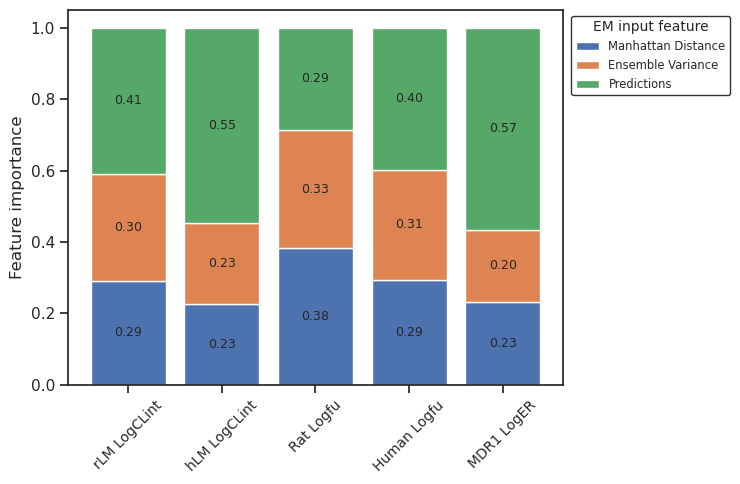

In [4]:
# Pivot the data for the stacked bar chart
stacked_data = feature_importances_df.pivot(index="Endpoint", columns="Feature", values="Importance")
stacked_data = stacked_data.reindex(endpoints).rename(index=endpoint_rename)

# Plot the figure
plt.figure(figsize=(8, 5))

bottom_stack = np.zeros(len(stacked_data))
for feature in feature_names:
    plt.bar(x=np.arange(len(stacked_data)), height=stacked_data[feature], label=feature, bottom=bottom_stack)
    for i, height in enumerate(stacked_data[feature]):
        plt.text(x=i, y=bottom_stack[i] + height / 2, s=f"{height:.2f}", ha='center', va='center', fontsize=9)
    bottom_stack += stacked_data[feature]

plt.xlabel("")
plt.xticks(np.arange(len(stacked_data)), stacked_data.index, rotation=45, fontsize=10)
plt.ylabel("Feature importance", fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1),
           fontsize='x-small', title='EM input feature', title_fontsize='small',
           frameon=True, fancybox=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.show()

## SHAP partial dependence

For every endpoint, compute the SHAP partial dependence of each input feature on the RF error model's prediction evaluated on the Test subset.


### rLM LogCLint ###



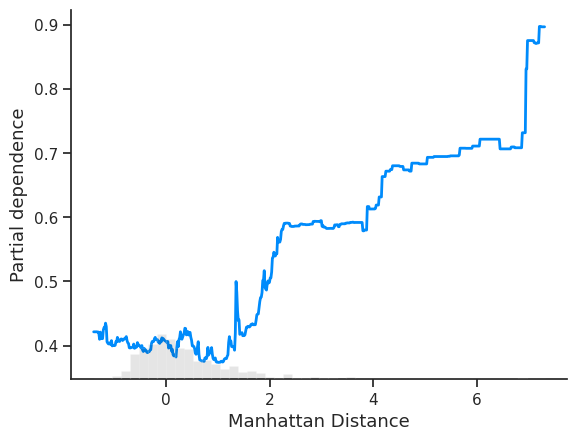

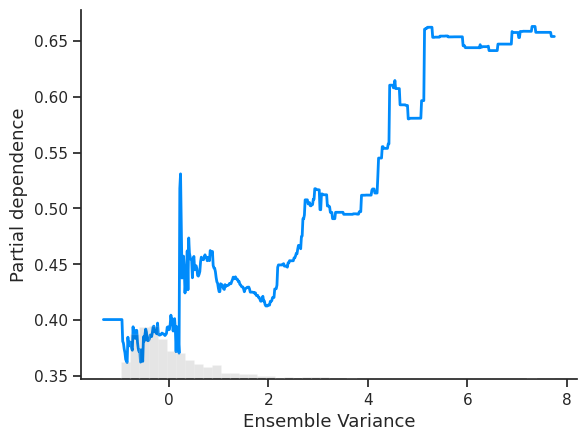

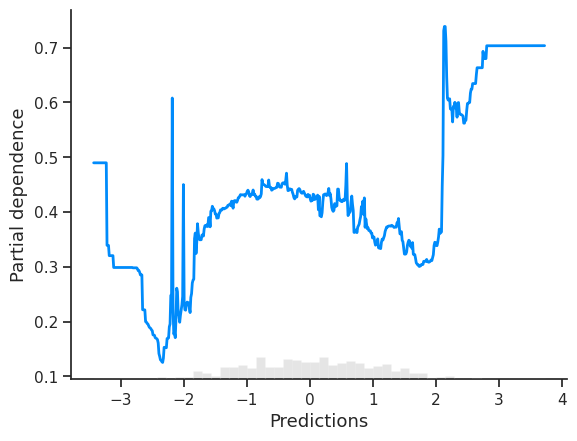


### hLM LogCLint ###



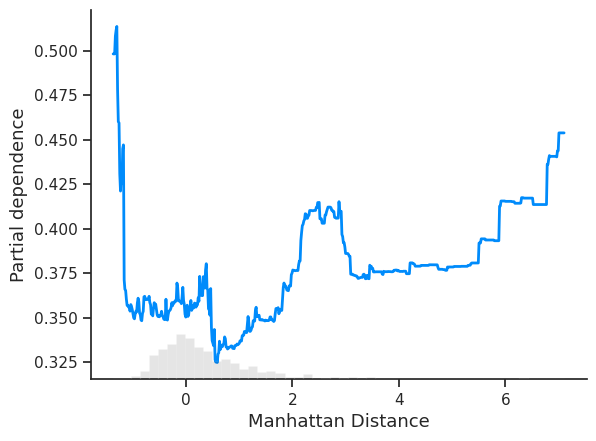

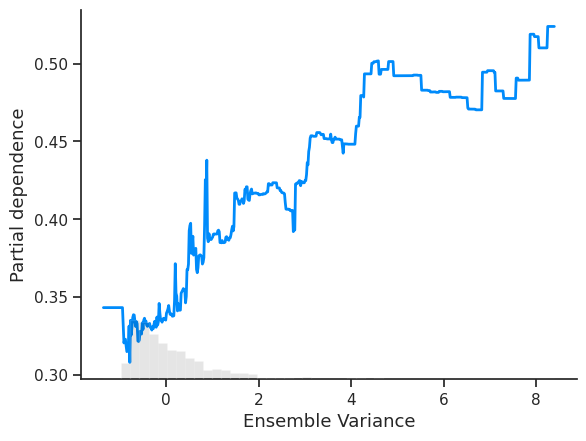

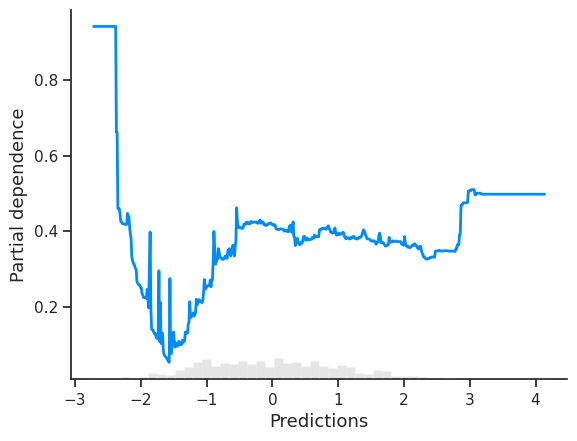


### LogFu-Rat ###



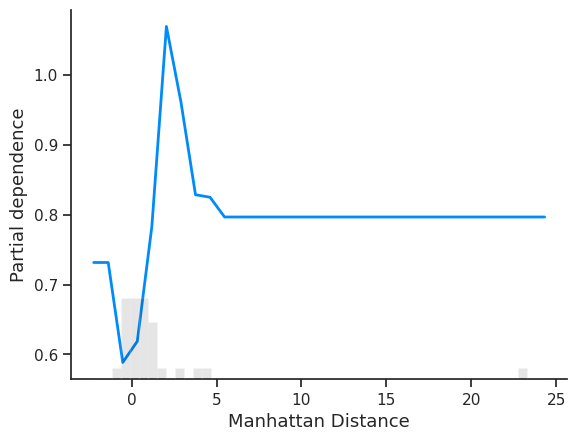

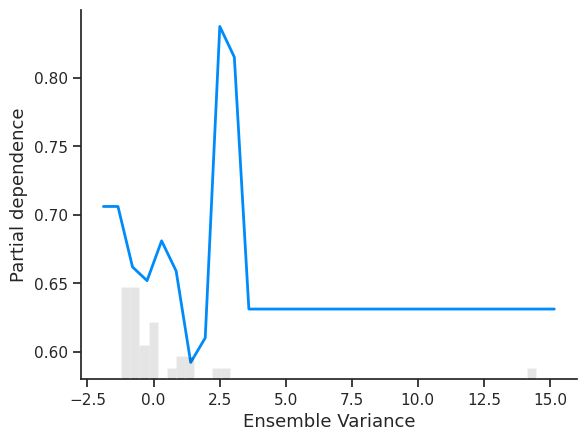

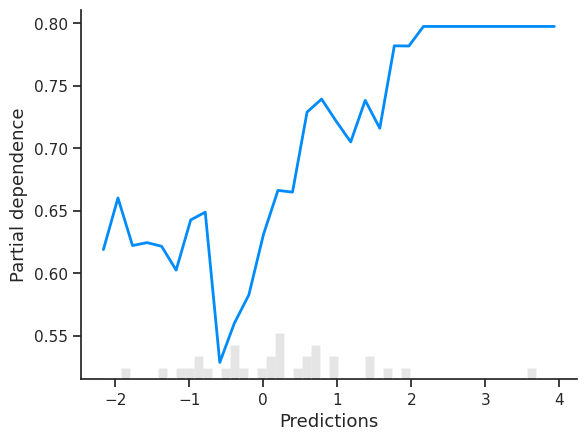


### LogFu-Human ###



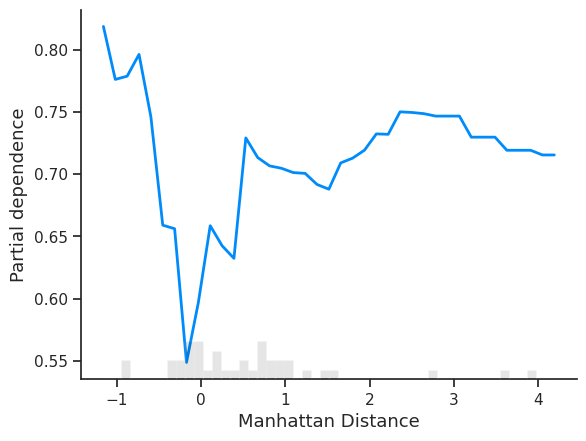

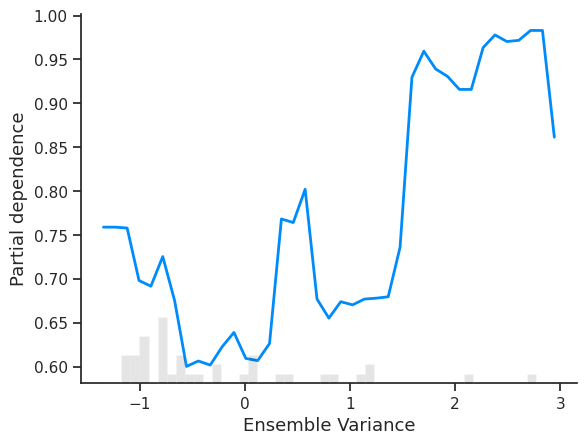

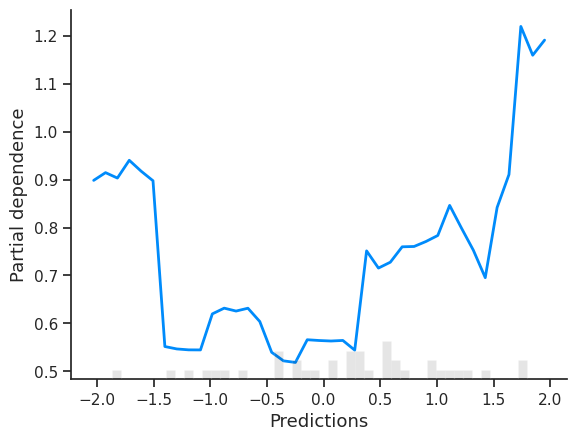


### MDCK-MDR1_LogER ###



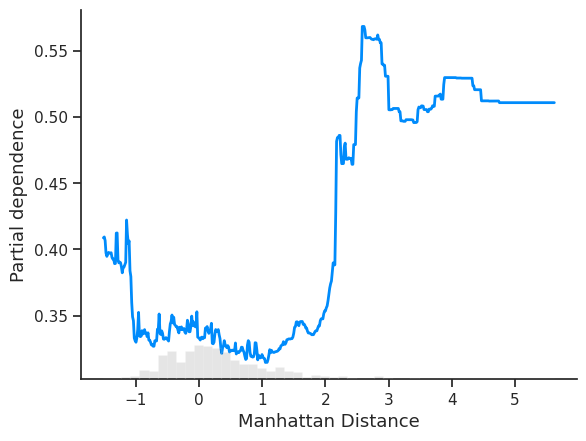

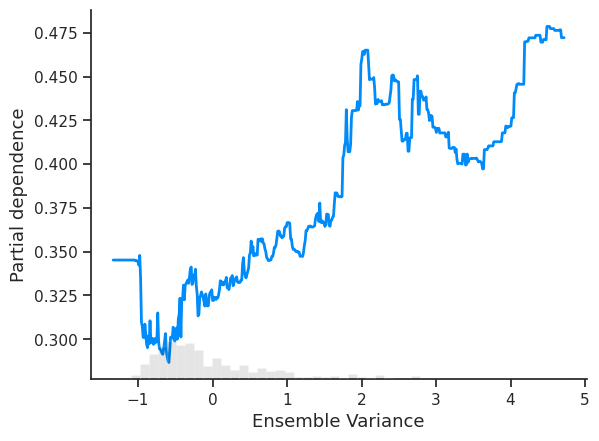

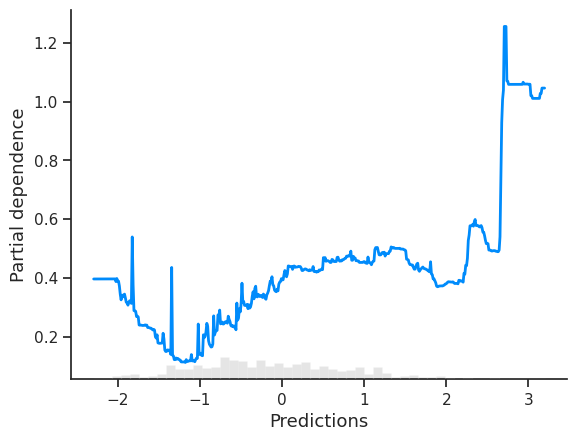

In [5]:
for endpoint, models_dict in endpoints_dict.items():
    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')

        # Load EM input data and select the Test subset
        em_data = pd.read_csv(f'unique_output/{model_id}/error_models/UQmetrics_predictions/data.csv')
        test_data = em_data[em_data['which_set'] == 'TEST']
        X_test = test_data.iloc[:, 3:-1]

        # Load RF error model
        model = pickle.load(open(f'unique_output/{model_id}/error_models/UQmetrics_predictions/UniqueRandomForestRegressor_model.pkl', 'rb'))
        model.feature_names_in_ = feature_names
        X_test.columns = feature_names

        # Plot the SHAP partial dependence for every input feature
        for feature in feature_names:
            shap.partial_dependence_plot(feature, model.predict, X_test,
                                         ice=False, model_expected_value=False, feature_expected_value=False,
                                         ylabel='Partial dependence', npoints=len(X_test))